### Checklist for submission

It is extremely important to make sure that:

1. Everything runs as expected (no bugs when running cells);
2. The output from each cell corresponds to its code (don't change any cell's contents without rerunning it afterwards);
3. All outputs are present (don't delete any of the outputs);
4. Fill in all the places that say `# YOUR CODE HERE`, or "**Your answer:** (fill in here)".
5. Never copy/paste any notebook cells. Inserting new cells is allowed, but it should not be necessary.
6. The notebook contains some hidden metadata which is important during our grading process. **Make sure not to corrupt any of this metadata!** The metadata may for example be corrupted if you copy/paste any notebook cells, or if you perform an unsuccessful git merge / git pull. It may also be pruned completely if using Google Colab, so watch out for this. Searching for "nbgrader" when opening the notebook in a text editor should take you to the important metadata entries.
7. Although we will try our very best to avoid this, it may happen that bugs are found after an assignment is released, and that we will push an updated version of the assignment to GitHub. If this happens, it is important that you update to the new version, while making sure the notebook metadata is properly updated as well. The safest way to make sure nothing gets messed up is to start from scratch on a clean updated version of the notebook, copy/pasting your code from the cells of the previous version into the cells of the new version.
8. If you need to have multiple parallel versions of this notebook, make sure not to move them to another directory.
9. Although not forced to work exclusively in the course `conda` environment, you need to make sure that the notebook will run in that environment, i.e. that you have not added any additional dependencies.

Failing to meet any of these requirements might lead to the submission not being validated meaning no feedback will be provided.

We advise you to perform the following steps before submission to ensure that requirements 1, 2, and 3 are always met: **Restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All). This might require a bit of time, so plan ahead for this. Finally press the "Save and Checkout" button before handing in, to make sure that all your changes are saved to this .ipynb file.

### Fill in name of notebook file
This might seem silly, but the version check below needs to know the filename of the current notebook, which is not trivial to find out programmatically.

You might want to have several parallel versions of the notebook, and it is fine to rename the notebook as long as it stays in the same directory. **However**, if you do rename it, you also need to update its own filename below:

In [1]:
nb_fname = "HA3.ipynb"

assert (nb_fname != "XXX.ipynb"), "Make sure to fill in the nb_fname variable above!"

### Fill in group number and member names:

In [2]:
NAME1 = "Zeren Wang"
NAME2 = "Hongbin Zhang"
GROUP = "66"

### Check Python version

In [3]:
from platform import python_version_tuple

assert (
    python_version_tuple()[:2] == ("3", "11")
), "You are not running Python 3.11. Make sure to run Python through the course Conda environment."

### Check that notebook server has access to all required resources, and that notebook has not moved

In [4]:
import os

nb_dirname = os.path.abspath("")
assignment_name = os.path.basename(nb_dirname)
assert assignment_name in [
    "HA1",
    "HA2",
    "HA3",
    "HA4",
], "[ERROR] The notebook appears to have been moved from its original directory"

### Verify correct nb_fname

In [5]:
from IPython.display import HTML, display

try:
    display(
        HTML(
            r'<script>if("{nb_fname}" != IPython.notebook.notebook_name) {{ alert("You have filled in nb_fname = \"{nb_fname}\", but this does not seem to match the notebook filename \"" + IPython.notebook.notebook_name + "\"."); }}</script>'.format(
                nb_fname=nb_fname
            )
        )
    )
except NameError:
    assert False, "Make sure to fill in the nb_fname variable above!"

### Verify that your notebook is up-to-date and not corrupted in any way

In [6]:
import sys

sys.path.append("..")
from ha_utils import check_notebook_uptodate_and_not_corrupted

check_notebook_uptodate_and_not_corrupted(nb_dirname, nb_fname)

Matching current notebook against the following URL:
http://raw.githubusercontent.com/dml-cth/deep-machine-learning/master/home-assignments/HA3/HA3.ipynb
[SUCCESS] No major notebook mismatch found when comparing to latest GitHub version. (There might be minor updates, but even that is the case, submitting your work based on this notebook version would be acceptable.)


# HA3 - Cats and dogs

<img src="https://cdn.pixabay.com/photo/2015/05/20/10/03/cat-and-dog-775116_960_720.jpg" alt="Image of cats and dogs" style="width: 500px;"/>

For this home assignment, we'll use the Kaggle dataset for the [Dogs vs. Cats competition](https://www.kaggle.com/c/dogs-vs-cats). It is comprised of 25k colour images of dogs and cats. Our goal with this assignment will be to create a classifier that can discriminate between cats or dogs.

The goal is to make sure that you all can independently create, train and evaluate a model using a popular deep learning framework. The focus is on implementing the models, and much of the surrounding code is provided for you. You are expected to understand the provided code.

## Using your CPU

While training neural networks most of the time happens on GPUs, this assignment is made in a way such that it is possible to run it on CPU. We highly advise you to do it. Note: **the cloud compute with GPUs that we povide in this course is to be used for project work**.

## Working efficiently:
* Before starting, take a look at the images we'll be using. This is a hard task, don't get discouraged if your first models perform poorly (several participants in the original competition didn't achieve an accuracy higher than 60%).
* Solving the computer labs and previous home assignments is a good way to get prepared for this assignment.
* In the first part of the assignment, we advise you to use smaller image sizes for for better efficiency (but you need to examine the resulting images and make sure that they are not too small and contain enough information for the classifier to succeed).
* Training for several epochs just to have your code break at the last validation step is incredibly frustrating and inefficient. Good practice is to first do a test run: a single epoch, a few batches etc.

**Requirements:**
- Whenever we ask you to plot anything, be sure to add a title and label the axes. If you're plotting more than one curve in the same plot, also add a legend.
- When we ask you to train an architecture, train it for a reasonable number of epochs. "Reasonable" here means you should be fairly confident that training for a higher number of epochs wouldn't impact your conclusions regarding the model's performance. When experimenting, a single epoch is often enough to tell whether your model setup has improved or not.

**IMPORTANT NOTES:**
- Some cells contain compiled tests. For them to work propery:
    - make sure to keep variable names. For example, if you are asked to create a training dataset, and `train_dataset` is passed to the test, then you should complete the task by updating `train_dataset` variable in your code. But, of course, you can create auxiliary variables.
    - make sure you are using the right environemnt. The tests will not work if you are using python 3.9, for example.
- You won't need to train neural networks in the Inspera test.

---
## Imports

In the following cell, add all the imports you'll use in this assignment.

In [7]:
from utils.tests import ha3_tests

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

---
## 1. Loading the data and preprocessing

In this part we will set up the data used in this assignment. You need to download it, then we'll walk you through how to make a custom Pytorch dataset abstraction. The abstraction enables you to visualise and play around with the image data and to finally create data loaders, which are necessary for the training.

The first step is to head to the [Kaggle website for the cats and dogs competition](https://www.kaggle.com/c/dogs-vs-cats/data) and download the data from there. You should download both the test and train folders together in one zip file (there is a `Download all` button at the bottom of the page). Unfortunately, you need to create a Kaggle account for this.

**Only necessary for tasks 4-6**: Downloading the data to your local computer is quite straight-forward. Sooner or later you will have to upload the data to the cloud instance and that is a bit more tricky. There are a few ways to do it:

 - Jupyter Notebook upload function. When starting the notebook server with the command `jupyter notebook` you are directed to a main page. In the top right corner there is an upload button.
 - Using [`scp`](https://linuxize.com/post/how-to-use-scp-command-to-securely-transfer-files/) to copy files via an ssh connection.
 - Using the [Kaggle CLI](https://github.com/Kaggle/kaggle-api). We have added it to the conda environment.

To begin with, download the data to your local computer and create a folder structure that resembles the following (obviously, the folder names are up to you):


         small_train             small_val                train                   val
              |                      |                      |                      |
              |                      |                      |                      |
        -------------          -------------          -------------          -------------
        |           |          |           |          |           |          |           |
        |           |          |           |          |           |          |           |
      cats        dogs       cats        dogs       cats        dogs       cats        dogs


The `small_train` and `small_val` folders have the training and validation samples for your smaller subset of the data from Kaggle's `train.zip`. Having a smaller dataset is a convenient way of testing ideas for faster prototyping.

The `train` and `val` folders should contain much more samples and represent a big dataset. It will be used for final optimization.

We provide you a notebook that shows how to achieve this folder structure (`create_project_notebook_structure.ipynb`), starting from the original `dogs-vs-cats.zip` file that you download from Kaggle. If you do use that notebook, we encourage you to understand how each step is being done, so you can generalize this knowledge to new datasets you'll encounter.

For the smaller dataset, we advise you to use 70% of the data as training data (and thereby the remaining 30% for validation data). However, for the larger dataset, you should decide how to split between training and validation.

- What percentage of the larger dataset did you decide to use for training/validation?
- Motivate your decision.

Both datasets are carved out of the 25000 labelled Kaggle images. The small dataset follows the
suggested 70/30 rule (1750 training / 750 validation images). For the bigger dataset I kept the
helper notebook's 50% subset (12500 images) and split it **90/10**, i.e. 11250 training and 1250
validation images.

Motivation: the validation set is only used to *compare* models (and to detect overfitting), while
every image given to the training set is what actually buys accuracy, so it is worth spending the
images where they pay off. 1250 validation images are still plenty to resolve the differences we
care about: if the accuracy is around 97%, the standard error of the estimate is
$\sqrt{0.97 \cdot 0.03 / 1250} \approx 0.5\%$, so differences larger than roughly 1-1.5
percentage points are meaningful. A 20% validation split would only shrink that to ~0.35% while
taking another 1250 images away from training - and on the CPU-only machine used here every epoch
also becomes noticeably slower, which matters because the CPU time is what limits how many
experiments (and epochs) we can afford.


Fill in the dataset paths (to be used later by your data loaders):

In [8]:
# TODO: Change the directories accordingly
# The folders are created by `create_project_notebook_structure.ipynb` and live next
# to this notebook, so relative paths are enough.
data_path = Path.cwd()

train_path = data_path / "train"
val_path = data_path / "val"
small_train_path = data_path / "small_train"
small_val_path = data_path / "small_val"

### 1.1 Dataset

To create data loaders we first need to create a dataset abstraction class. The purpose of a data loader is to efficiently provide the CPU/GPU with mini-batches of data. We now work with data complex enough to actually warrant the use of data loaders. In particular, we don't want to load all images into memory at once.

Like before, the data loader is an instance of the Pytorch [`DataLoader`](https://pytorch.org/docs/stable/data.html?highlight=dataloader#torch.utils.data.DataLoader) which wraps a class that inherits from [`Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset), that we create ourselves.
Image classification is such a common task that Pytorch provides a ready-to-use dataset class for this task, called [`ImageFolder`](https://pytorch.org/vision/stable/datasets.html?highlight=imagefolder#imagefolder).
Using this class however, is rather opaque so for your understanding we will show you how to construct a custom dataset class. If you know this method, you will be able to create a data loader for any dataset you may encounter.

We construct a class `DogsCatsData` as a subclass of `Dataset`. 
The dataset subclass holds the actual data, or at least provides access to it.
To make it work with the `DataLoader` class we need to implement two methods:

- `__getitem__(self, index)`: return the `index`'th sample, i.e. a single pair of (image, label)
- `__len__(self)`: simply return the total number of samples $N$ in the dataset.

These methods are so called Python "magic" methods, signified by the leading and closing double underscores.
They typically enable special syntax for a class: `__getitem__` enables indexing of a class, and `__len__` enables calling the `len` function:
```python
# Consider an instance `data` of a class `MyDataset` implementing `__getitem__` and `__len__`
data[10] # returns the item with index 10 in `data`
len(data) # returns the length/size of `data`
```
We will return to why these are needed in the `DataLoader` wrapping class

Now, to the actual implementation: The idea is to have the dataset class only store the filenames of the images (and the corresponding label), not the images themselves. We will find and store the filenames in the constructor. The `__getitem__` method will use the index to look up the correct filename and load it into memory.
The `__len__` method is left for you to implement.

Being able to use and understand code you have not written is an important ability. Below you are required to interact with the dataset class with a simple completion of the implementation and by extracting some data from the class. This is partly to ensure that you understand this specific class and partly to show you some tools for exploring new code.

In [9]:
from itertools import chain

from PIL import Image
from torch.utils.data import Dataset


class DogsCatsData(Dataset):
    def __init__(self, root, transform, dog_label=1, cat_label=0):
        """Constructor

        Args:
            root (Path/str): Filepath to the data root, e.g. './small_train'
            transform (Compose): A composition of image transforms, see below.
        """

        root = Path(root)
        if not (root.exists() and root.is_dir()):
            raise ValueError(f"Data root '{root}' is invalid")

        self.root = root
        self.transform = transform
        self._dog_label = dog_label
        self._cat_label = cat_label

        # Collect samples, both cat and dog and store pairs of (filepath, label) in a simple list.
        self._samples = self._collect_samples()

    def __getitem__(self, index):
        """Get sample by index

        Args:
            index (int)

        Returns:
             The index'th sample (Tensor, int)
        """
        # Access the stored path and label for the correct index
        path, label = self._samples[index]
        # Load the image into memory
        img = Image.open(path)
        # Perform transforms, if any.
        if self.transform is not None:
            img = self.transform(img)
        return img, label

    def __len__(self):
        """Total number of samples"""
        return len(self._samples)

    def _collect_samples(self):
        """Collect all paths and labels

        Helper method for the constructor
        """
        # Iterator over dog filpath
        dog_paths = self._collect_imgs_sub_dir(self.root / "dogs")
        # Iterator of pairs (path, dog label)
        # Again, we use the `map` function to create an iterator. It's use is not as common as the so called
        # 'list comprehension' you've previously seen, but a good alternative to have seen.
        dog_paths_and_labels = map(lambda path: (path, self._dog_label), dog_paths)
        # Same for cats
        cat_paths = self._collect_imgs_sub_dir(self.root / "cats")
        cat_paths_and_labels = map(lambda path: (path, self._cat_label), cat_paths)
        # Sorting is not strictly necessary, but filesystem globbing (wildcard search) is not deterministic,
        # and consistency is nice when debugging.
        return sorted(
            list(chain(dog_paths_and_labels, cat_paths_and_labels)),
            key=lambda x: x[0].stem,
        )

    @staticmethod
    def _collect_imgs_sub_dir(sub_dir: Path):
        """Collect image paths in a directory

        Helper method for the constructor
        """
        if not sub_dir.exists():
            raise ValueError(
                f"Directory '{sub_dir}' does not exist. Are you sure you have the correct path?"
            )
        return sub_dir.glob("*.jpg")

    def get_sample_by_id(self, id_):
        """Get sample by image id

        Convenience method for exploration.
        The indices does not correspond to the image id's in the filenames.
        Here is a (rather inefficient) way of inspecting a specific image.

        Args:
            id_ (str): Image id, e.g. `dog.321`
        """
        id_index = [path.stem for (path, _) in self._samples].index(id_)
        return self[id_index]

Show that you understand the implementation by creating an instance called `example_dataset` of it. Create it from the small training set.
Use the instance to:
- print the number of samples in it
- print the label of the second sample, note that this is a number (0 or 1)

In [10]:
# The Dataset constructor has a transform attribute, we will cover it below. Just use this for now:
from torchvision.transforms import Compose

transform = Compose([ToTensor()])
example_dataset = DogsCatsData(small_train_path, transform=transform)
number_of_samples = len(example_dataset)
# Indexing uses the `__getitem__` method implemented above; `[1]` is the second sample.
label = example_dataset[1][1]

print(f"The number of samples is: {number_of_samples}")
print(f"The label of the second sample is: {label}")

The number of samples is: 1750
The label of the second sample is: 0


In [11]:
# Test case for `number_of_samples`
ha3_tests.test_number_of_samples(example_dataset, number_of_samples, DogsCatsData)

Test passed


In [12]:
# Test case for `label`
ha3_tests.test_label(example_dataset, label, DogsCatsData)

Test passed


It is vital to explore your data, but it can be tricky to deal with images in the tensor format.
To aid you, use the below helper function to visually inspect your images.

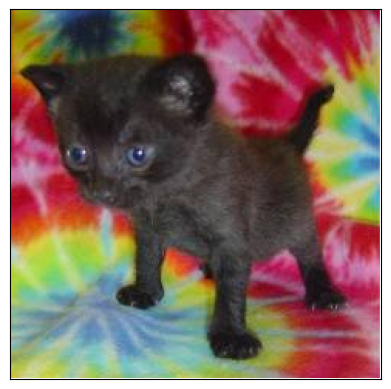

In [13]:
def display_image(axis, image_tensor):
    """Display a tensor as an image

    Args:
        axis (pyplot axis)
        image_tensor (torch.Tensor): tensor with shape (num_channels=3, width, heigth)
    """

    # See hint above
    if not isinstance(image_tensor, torch.Tensor):
        raise TypeError(
            "The `display_image` function expects a `torch.Tensor` "
            + "use the `ToTensor` transformation to convert the images to tensors."
        )

    # The imshow commands expects a `numpy array` with shape (3, width, height)
    # We rearrange the dimensions with `permute` and then convert it to `numpy`
    image_data = image_tensor.permute(1, 2, 0).numpy()
    height, width, _ = image_data.shape
    axis.imshow(image_data)
    axis.set_xlim(0, width)
    # By convention when working with images, the origin is at the top left corner.
    # Therefore, we switch the order of the y limits.
    axis.set_ylim(height, 0)
    axis.set_xticks([])
    axis.set_yticks([])


# Example usage
_, axis = plt.subplots()
some_random_index = 453
# Here we use the __getitem__ method as a "magic" method.
# Implementing it for a class, enables square bracket '[]' indexing
image_tensor, label = example_dataset[some_random_index]
display_image(axis, image_tensor)

### 1.2 Preprocessing 
The `DogsCatsData` class constructor has an argument called `transform`. It allows us to transform or preprocess all the images in a batch, from the raw image data to a more suitable format. There are multiple motivations for preprocessing:

- Some transformations might be needed to actually make the data work with our network (reshaping, permuting dimensions et c.).
- Make the training more efficient by making the input dimensions smaller, e.g. resizing, cropping.
- Artificially expanding the training data through [data augmentation](https://cartesianfaith.com/2016/10/06/what-you-need-to-know-about-data-augmentation-for-machine-learning/)
- We have some clever idea of how to change the data to create a simpler optimisation problem.

We do not expect you to do data augmentation, but feel free to preprocess the data as you see fit. Use the [documentation](https://pytorch.org/vision/stable/transforms.html#torchvision-transforms) to view available transforms. Extra important is the `Compose` transformation, which is a meta-transformation which composes actual ones, and the `ToTensor` transformation which is the simplest way to go from image to tensor format.


Hints:
- Revisit the `DogsCatsData` example usage to see how to use the `Compose` and `ToTensor` transformations.
- When feeding the images to your CNN, you'll probably want all of them to have the same spatial size, even though the .jpeg files differ in this. Resizing the images can be done using the previously mentioned Pytorch Transforms.
- Resizing the images to a smaller size while loading them can be beneficial as it speeds up training. The CNN's do surprisingly well on 64x64 images. Shorter training cycles give you more time to experiment! **Note**: The MobileNetV2 network used later in this assignment is specialised for images that are 224x224.

We encourage you to explore the data and choose transformations that you believe to be useful. For exploration we provide you with a helper function to visually compare transformations side by side:

In [14]:
def compare_transforms(transformations, index):
    """Visually compare transformations side by side.
    Takes a list of DogsCatsData datasets with different compositions of transformations.
    It then display the `index`th image of the dataset for each transformed dataset in the list.

    Example usage:
        compare_transforms([dataset_with_transform_1, dataset_with_transform_2], 0)

    Args:
        transformations (list(DogsCatsData)): list of dataset instances with different transformations
        index (int): Index of the sample in the dataset you wish to compare.
    """

    # Here we combine two functions from basic python to validate the input to the function:
    # - `all` takes an iterable (something we can loop over, e.g. a list) of booleans
    #    and returns True if every element is True, otherwise it returns False.
    # - `isinstance` checks whether a variable is an instance of a particular type (class)
    if not all(isinstance(transf, Dataset) for transf in transformations):
        raise TypeError(
            "All elements in the `transformations` list need to be of type Dataset"
        )

    num_transformations = len(transformations)
    fig, axes = plt.subplots(1, num_transformations)

    # This is just a hack to make sure that `axes` is a list of the same length as `transformations`.
    # If we only have one element in the list, `plt.subplots` will not create a list of a single axis
    # but rather just an axis without a list.
    if num_transformations == 1:
        axes = [axes]

    for counter, (axis, transf) in enumerate(zip(axes, transformations)):
        axis.set_title(f"transf: {counter}")
        image_tensor = transf[index][0]
        display_image(axis, image_tensor)

    plt.show()

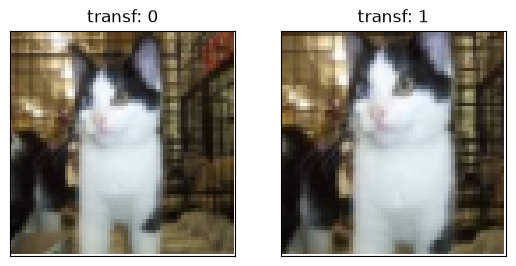

In [15]:
# Explore your dataset in this cell, you do not need to produce any results.
img_size = 64

# MobileNetV2 (section 4) was pre-trained on ImageNet, so the images are normalised
# with the ImageNet mean and standard deviation. The same normalisation is used for
# the models trained from scratch, so that the preprocessing is identical everywhere.
normalize = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = Compose([Resize((img_size, img_size)), ToTensor(), normalize])
val_transform = Compose([Resize((img_size, img_size)), ToTensor(), normalize])

train_dataset = DogsCatsData(small_train_path, transform=train_transform)
val_dataset = DogsCatsData(small_val_path, transform=val_transform)

# Visually compare a few preprocessing options. The datasets below are only used for
# the plots, so they skip the normalisation (which would distort the colours).
compare_transforms(
    [
        DogsCatsData(
            small_train_path,
            transform=Compose([Resize((img_size, img_size)), ToTensor()]),
        ),
        DogsCatsData(
            small_train_path,
            transform=Compose(
                [RandomResizedCrop(img_size, scale=(0.6, 1.0)), ToTensor()]
            ),
        ),
    ],
    0,
)

Normalisation of the training data is popular in pre-processing. What is the argument or intuition for why this is a beneficial transformation?

Normalisation rescales every input channel so that it has (approximately) zero mean and unit
variance. There are three arguments for it:

1. **Optimisation / conditioning.** The inputs are the first layer's weights multiplied by the raw
   pixel values. If the inputs are e.g. in $[0, 1]$ with a large common mean, the loss surface of
   the first layer is badly conditioned (a long, thin valley), and gradient-based optimisers make
   very slow progress along it. Centering and rescaling the inputs removes the first-order part of
   that effect, so all weights can be learned at comparable speeds.
2. **Keeping the non-linearities in their responsive regime.** Large inputs produce large pre-
   activations; the sigmoids of the network (including the output sigmoid) then saturate, and the
   gradient there is essentially zero, so learning stalls.
3. **Making the preprocessing of the two models compatible.** MobileNetV2 was pre-trained on
   ImageNet images that were normalised with exactly these statistics, so feeding it images
   normalised in the same way puts the pre-trained features in the regime they were optimised for.
   (For the same reason we do *not* normalise the images used for the visualisations, where the
   operation would only distort the colours.)

Intuition: subtracting the mean removes the part that every image has in common (the average
colour/brightness of the dataset) and keeps the part that varies between images - which is where
the class information is.


### 1.3 Data loaders
With our dataset class implementation in place, creating a `DataLoader` instance is simple.

The data loader class wraps the dataset and provides a way to iterate over batches in the training loop.
To produce batches, it gets the total number of samples $N$ with the dataset's `__len__` method.
It divides the indices $1, \dots, N$ into equally sized index batches with $B$ (batch size) elements. A particular batch with pairs of image and label is created by calling the dataset's `__getitem__` method with the indices in the batch. NB: the last batch in an epoch might be smaller if $N$ is not divisible by $B$.

Create the data loaders needed for training (use the small version of the data), in the cell below.
The `DataLoader` class is documented [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) , but it's not that much to it.
You simply create a data loader with a dataset instance and some other (self-explanatory) settings:

```python
train_dataloader = DataLoader(example_dataset, batch_size=batch_size, shuffle=True)
```

Create data loaders required for training and validation.

Hints:
- The specified `batch_size` should be chosen so that you train fast but don't run out of memory. You need to figure this out empirically; start small and increase the batch size until you run out of memory. Beyond this pragmatic approach, feel free to contribute to the highly contested scientific debate about the relation between batch size and generalisation.
- The `DataLoader` constructor takes an optional argument `num_workers`, which defaults to `0` if not provided. Setting a higher number creates multiple threads which load batches concurrently. This can speed up training considerably.

In [16]:
batch_size = 32

# `shuffle=True` only for the training set: the validation set is only used for
# evaluation, where the order does not matter. `num_workers > 0` loads and resizes
# the images in parallel with the training loop.
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=4
)
val_dataloader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=4
)

In [17]:
# Test case for `train_dataloader`
ha3_tests.test_dataloader(train_dataloader)

Test passed


In [18]:
# Test case for `val_dataloader`
ha3_tests.test_dataloader(val_dataloader)

Test passed


What batch size did you use and why?

`batch_size = 32`.

With 1750 training images this gives 55 parameter updates per epoch, which is a good compromise on
a CPU-only machine: the batches are small enough to keep the per-step cost low and to provide
fairly frequent updates, but large enough for the convolutions (and the MKL/oneDNN kernels behind
them) to work efficiently. Memory is not the binding constraint - a batch of 32 images at 224x224
needs only a few hundred MB of activations - so the batch size is really limited by how much
compute per update is useful. For the big dataset, where each epoch is expensive, I double the
batch size to 64 to reduce the Python/optimiser overhead per image.

The trade-off to be aware of: smaller batches mean noisier gradient estimates, which acts as a mild
regulariser and often generalises slightly better, whereas very large batches reduce the number of
updates per pass over the data (and can be a little worse at the same *number of epochs* unless the
learning rate is scaled up accordingly).


---
## 2. Training

### 2.1 The first model

Now, it's time to create a model called `FirstCnn`. To begin with, you have to create a CNN to an exact specification. After that, you will get the chance to be more creative.

For the first model, create a network that:
- Inherits from [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module)
- Implements a constructor `__init__(self, img_size)`, a `forward(self, input_batch)` method and whatever other helper methods you deem necessary. Note that a (square) image size should be a parameter in the model's constructor. While not strictly necessary, it is an acceptable way of handling varying input dim's and it is convenient for testing.
- Can handle square images of arbitrary size and arbitrary large mini-batch sizes (within memory limits, of course). You may assume that there are always three colour channels, i.e., a mini-batch will have the shape `(batch size = B, num channels = 3, img size = D, D)`
- Has layers:
    1. Two convolutional layers, each with 10 filters, kernel size = 3, stride = 1, padding = 0
    2. A single fully connected layer.
    - *Note:*
        - Related layers such as a pooling operation are optional.
        - Choose suitable activation functions.
        - Take the layers from [`torch.nn`](https://pytorch.org/docs/stable/nn.html) module, and **not** from `torch.nn.functional` module. 
- Outputs the probability of the image belonging to the class 'dog'. Technically the output should consist of `B` probabilities, one for each image in the mini-batch and so have the shape `(B,)`.

Hints:

- The subpage for [`torch.nn`](https://pytorch.org/docs/stable/nn.html) is a good place to find the layer specifics.
- Going from the last CNN layer to the final fully connected layer is not trivial. The convolutions produces feature maps which we can think of as an image with many channels, while the fully connected layer expects a row vector as input. Calculate how many output neurons the convolutions produce and use `.reshape` to make your tensor fit the fully connected layer. It is also common to see the `.view` and `.squeeze` methods to do the same thing. They basically do the same thing (apart from some differences in internal memory management) but are less transparent. *Hint within the hint:* remember that the fully connected layers expects a *batch* of 1D tensors. 


In [19]:
# class FirstCnn...
#    def __init__(self, img_size):
#       ...
#    ...


class FirstCnn(nn.Module):
    """A small convolutional network with the architecture specified in the task."""

    def __init__(self, img_size):
        super().__init__()
        self.img_size = img_size
        self.conv1 = nn.Conv2d(3, 10, 3)
        self.conv2 = nn.Conv2d(10, 10, 3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(self._num_features(img_size), 1)
        self.sigmoid = nn.Sigmoid()

    @staticmethod
    def _num_features(img_size):
        """Number of values produced by the convolutional part for a square image."""
        size = img_size
        for _ in range(2):  # conv(kernel=3, padding=0) followed by 2x2 max pooling
            size = (size - 2) // 2
        return 10 * size * size

    def forward(self, input_batch):
        x = self.pool(self.relu(self.conv1(input_batch)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.flatten(x)
        # The fully connected layer expects a batch of 1D inputs, so `x` is flattened
        # from (B, 10, D, D) to (B, 10 * D * D). One probability of 'dog' per image,
        # i.e. the output has shape (B,).
        return self.sigmoid(self.fc(x)).squeeze(-1)


first_model = FirstCnn(img_size)

In [20]:
# Test case 1 for `FirstCnn`
# Note that the test takes the actual class, not an instance of it, as input.
ha3_tests.test_model(FirstCnn)

Test passed.


In [21]:
# Test case 2 for `FirstCnn`
ha3_tests.test_architecture(FirstCnn)

Test passed


You have been told that one of the benefits of CNN is that it can handle input of different sizes. Yet, you needed to know the image size in the constructor.
Explain how you made your model handle different input sizes and why it is necessary, despite it being a CNN.

The convolutional part of the model is size-agnostic: `nn.Conv2d` slides the same kernels over
whatever spatial extent it is given, and pooling/flattening follows the resulting shapes. The
constraint comes from the **fully connected layer**: `nn.Linear` owns a fixed weight matrix of
shape `(num_features, 1)`, so the number of values produced by the convolutional stack must be
known when the model is built. Since that number depends on the image size, `img_size` has to be
passed to the constructor, and the model then computes it with `FirstCnn._num_features` (each
convolution with kernel 3 and no padding removes one pixel on each side, each 2x2 max pooling
halves the size, so a square image of side $D$ ends up with
$10 \cdot \lfloor (\lfloor (D-2)/2 \rfloor - 2)/2 \rfloor^2$ values, e.g. 1960 for $D=64$ and
29160 for $D=224$). Nothing else in the architecture depends on the size - which is exactly what
the test in the next-but-one cell demonstrates by instantiating the class with $D=224$ and with
$D=32$.

A clean way to remove the dependency altogether is a global pooling layer before the classifier
(`nn.AdaptiveAvgPool2d(1)` averages each feature map to a single number, giving the classifier a
fixed input of 10 values regardless of the resolution). That is what `ImprovedCnn` and the
transfer learning head do. Note, however, that being *able* to run at any size is not the same as
being *equally good* at any size: a model trained at 64x64 sees objects at a different scale than
one trained at 224x224, so the accuracy does drop when it is applied far away from its training
resolution.


### 2.2 The training loop

You have already seen quite a few training loops in the preparations. Below we provide you with an example of a basic one that you can use.
You need to provide an implementation that maps network outputs (probabilites) to hard labels. It should be a vectorised implementation.

In [22]:
def output_to_label(z):
    """Map network output z to a hard label {0, 1}

    Args:
        z (Tensor, any size): Probabilities for each sample in a batch.
    Returns:
        c (Tensor, same size as z): Hard label {0, 1} for each sample in a batch
    """
    # A probability above 0.5 is classified as 'dog'. The comparison is vectorised
    # (it works for any shape, not only for a single sample) and `.to(z.dtype)` keeps
    # both the data type and the device of the input.
    return (z > 0.5).to(z.dtype)

In [23]:
# Test case for `output_to_label` function
ha3_tests.test_output_to_label(output_to_label)

Test passed


In [24]:
def training_loop(
    model, optimizer, loss_fn, train_loader, val_loader, num_epochs, print_every
):
    print("Starting training")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    train_losses, train_accs, val_losses, val_accs = [], [], [], []

    for epoch in range(1, num_epochs + 1):
        model, train_loss, train_acc = train_epoch(
            model, optimizer, loss_fn, train_loader, val_loader, device, print_every
        )
        val_loss, val_acc = validate(model, loss_fn, val_loader, device)
        print(
            f"Epoch {epoch}/{num_epochs}: "
            f"Train loss: {sum(train_loss)/len(train_loss):.3f}, "
            f"Train acc.: {sum(train_acc)/len(train_acc):.3f}, "
            f"Val. loss: {val_loss:.3f}, "
            f"Val. acc.: {val_acc:.3f}"
        )
        train_losses.extend(train_loss)
        train_accs.extend(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
    return model, train_losses, train_accs, val_losses, val_accs


def train_epoch(
    model, optimizer, loss_fn, train_loader, val_loader, device, print_every
):
    # Train:
    model.train()
    train_loss_batches, train_acc_batches = [], []
    num_batches = len(train_loader)
    for batch_index, (x, y) in enumerate(train_loader, 1):
        inputs, labels = x.to(device), y.to(device)
        optimizer.zero_grad()
        z = model.forward(inputs)
        loss = loss_fn(z, labels.float())
        loss.backward()
        optimizer.step()
        train_loss_batches.append(loss.item())

        hard_preds = output_to_label(z)
        acc_batch_avg = (hard_preds == labels).float().mean().item()
        train_acc_batches.append(acc_batch_avg)

        # If you want to print your progress more often than every epoch you can
        # set `print_every` to the number of batches you want between every status update.
        # Note that the print out will trigger a full validation on the full val. set => slows down training
        if print_every is not None and batch_index % print_every == 0:
            val_loss, val_acc = validate(model, loss_fn, val_loader, device)
            model.train()
            print(
                f"\tBatch {batch_index}/{num_batches}: "
                f"\tTrain loss: {sum(train_loss_batches[-print_every:])/print_every:.3f}, "
                f"\tTrain acc.: {sum(train_acc_batches[-print_every:])/print_every:.3f}, "
                f"\tVal. loss: {val_loss:.3f}, "
                f"\tVal. acc.: {val_acc:.3f}"
            )

    return model, train_loss_batches, train_acc_batches


def validate(model, loss_fn, val_loader, device):
    val_loss_cum = 0
    val_acc_cum = 0
    model.eval()
    with torch.no_grad():
        for batch_index, (x, y) in enumerate(val_loader, 1):
            inputs, labels = x.to(device), y.to(device)
            z = model.forward(inputs)

            batch_loss = loss_fn(z, labels.float())
            val_loss_cum += batch_loss.item()
            hard_preds = output_to_label(z)
            acc_batch_avg = (hard_preds == labels).float().mean().item()
            val_acc_cum += acc_batch_avg
    return val_loss_cum / len(val_loader), val_acc_cum / len(val_loader)

Use the training loop to train your model, using the two dataloaders you created earlier. Train for a reasonable amount of epochs, so as to get a good sense of how well this architecture performs.

Hints:
- Which `loss_fn` should you use? Think first about what is suitable for this problem, not what seems to work better empirically.
- Training on a CPU is slow and in the beginning you just want to verify that your architecture actually produces a predicition with the correct shape. Make everything you can to speed up the prototyping phase, e.g. train only for a single epoch and make the images ridiculously small.

In [25]:

# The network outputs a probability of 'dog', so the binary cross-entropy is the
# natural loss: it is the negative log-likelihood of the label given the prediction.
loss_fn = nn.BCELoss()

NUM_EPOCHS_FIRST = 12
first_optimizer = torch.optim.Adam(first_model.parameters(), lr=1e-3)
(
    first_model,
    first_train_losses,
    first_train_accs,
    first_val_losses,
    first_val_accs,
) = training_loop(
    first_model,
    first_optimizer,
    loss_fn,
    train_dataloader,
    val_dataloader,
    num_epochs=NUM_EPOCHS_FIRST,
    # An extra validation every 25 batches is cheap at this image size and gives a
    # finer-grained view of the training progress.
    print_every=25,
)

Starting training


	Batch 25/55: 	Train loss: 0.693, 	Train acc.: 0.531, 	Val. loss: 0.687, 	Val. acc.: 0.557


	Batch 50/55: 	Train loss: 0.681, 	Train acc.: 0.557, 	Val. loss: 0.686, 	Val. acc.: 0.566


Epoch 1/12: Train loss: 0.686, Train acc.: 0.552, Val. loss: 0.699, Val. acc.: 0.539


	Batch 25/55: 	Train loss: 0.661, 	Train acc.: 0.605, 	Val. loss: 0.666, 	Val. acc.: 0.598


...

	Batch 50/55: 	Train loss: 0.418, 	Train acc.: 0.823, 	Val. loss: 0.664, 	Val. acc.: 0.693


Epoch 11/12: Train loss: 0.412, Train acc.: 0.811, Val. loss: 0.719, Val. acc.: 0.657


	Batch 25/55: 	Train loss: 0.394, 	Train acc.: 0.846, 	Val. loss: 0.651, 	Val. acc.: 0.688


	Batch 50/55: 	Train loss: 0.378, 	Train acc.: 0.818, 	Val. loss: 0.695, 	Val. acc.: 0.689


Epoch 12/12: Train loss: 0.382, Train acc.: 0.832, Val. loss: 0.675, Val. acc.: 0.680


Which loss function did you use and why? In our "Cats vs Dogs" problem, the dataset is balanced in terms of classes. What would you change if there was a class imbalance (for example, if we had much less dog images)?

`nn.BCELoss()`, i.e. the (binary) cross-entropy applied to the sigmoid output.

The reason is that the question the network answers has to be a *probabilistic* one: the output
$\hat{p}$ of the sigmoid is interpreted as $P(\text{dog} \mid \text{image})$, and the loss
$-\left[y \log \hat{p} + (1-y) \log (1 - \hat{p})\right]$ is exactly the negative log-
likelihood of the observed label under that model. It is not just a proxy for accuracy: it penalises
confident wrong predictions very strongly (the penalty is unbounded as $\hat{p} \to 1 - y$), which
is why it also gives the smooth, well-behaved gradients that the optimiser needs early in training.
For a two-class problem, cross-entropy is equivalent (up to the parameterisation) to the sigmoid
plus BCE, which is why we do not need a two-output softmax - and the assignment asks for a single
probability anyway.

On class imbalance: with equally many cats and dogs the two terms of the loss are on the same scale,
so the model is not biased towards either class a priori, and 0.5 is the optimal decision threshold
(see `output_to_label`). If dogs were much rarer, then (i) most minibatches would contain few (or no)
dogs, and the gradient would be dominated by cats, so the cheapest fix is to weight the rarer class
more in the loss (`nn.BCEWithLogitsLoss(pos_weight=n_cats/n_dogs)`) or to resample the data
(`WeightedRandomSampler`, or simply oversampling the minority class); (ii) plain accuracy would
become useless, since "always cat" already scores high - so one should report *balanced* metrics
(balanced accuracy, per-class recall/precision, AUC or the confusion matrix) instead; and (iii) the
0.5 threshold would no longer be optimal either, and moving it towards the class prior is often
worth a point or two of the minority-class recall.


### 2.3 Visualisation

Create two plots. In one of them, plot the loss in the training and the validation datasets. In the other one, plot the accuracy in the training and validation datasets.
Note that the given training loop produces metrics at different intervals for training and validation, make sure that you align your metrics in a way that makes sense.

**Note also:** this kind of visualization will have to be done more times in this notebook. We advise you to write a function that does the plotting and re-use it later.

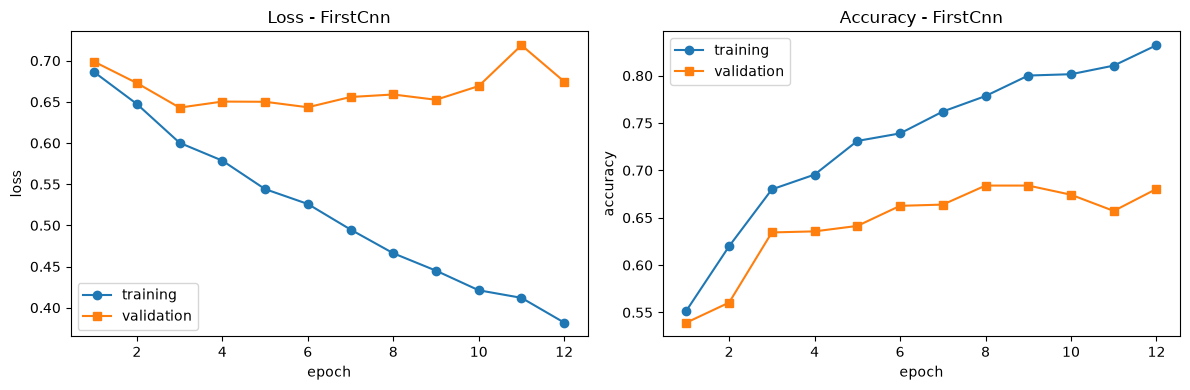

In [26]:
def to_epochs(values, num_epochs):
    """Average a per-batch training curve so that it has one value per epoch."""
    return np.asarray(values, dtype=float).reshape(num_epochs, -1).mean(axis=1)


def plot_curves(train_losses, train_accs, val_losses, val_accs, num_epochs, title=""):
    """Plot the loss and the accuracy on the training and the validation sets.

    The training metrics are recorded once per batch while the validation metrics are
    recorded once per epoch, so the training curves are averaged per epoch to make the
    two comparable.
    """
    train_losses = to_epochs(train_losses, num_epochs)
    train_accs = to_epochs(train_accs, num_epochs)
    epochs = np.arange(1, num_epochs + 1)

    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, train_losses, "o-", label="training")
    axes[0].plot(epochs, val_losses, "s-", label="validation")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title(f"Loss{title}")
    axes[0].legend()

    axes[1].plot(epochs, train_accs, "o-", label="training")
    axes[1].plot(epochs, val_accs, "s-", label="validation")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_title(f"Accuracy{title}")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_comparison(curves, metric="acc", title=""):
    """Compare one metric of several models.

    Args:
        curves (dict): name -> (train_values, val_values, num_epochs)
        metric (str): either 'acc' or 'loss'
    """
    ylabel = {"acc": "accuracy", "loss": "loss"}[metric]

    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, (train_values, val_values, num_epochs) in curves.items():
        train_curve = to_epochs(train_values, num_epochs)
        axes[0].plot(np.arange(1, num_epochs + 1), train_curve, "o-", label=name)
        axes[1].plot(np.arange(1, len(val_values) + 1), val_values, "s-", label=name)
    for axis, split in zip(axes, ["training", "validation"]):
        axis.set_xlabel("epoch")
        axis.set_ylabel(ylabel)
        axis.set_title(f"{split.capitalize()} {ylabel} {title}")
        axis.legend()
    plt.tight_layout()
    plt.show()


plot_curves(
    first_train_losses,
    first_train_accs,
    first_val_losses,
    first_val_accs,
    NUM_EPOCHS_FIRST,
    title=" - FirstCnn",
)

Based on these, what would you suggest for improving your model? Why?

The two curves tell a clear story. The **training** accuracy climbs steadily, from 55% in the first
epoch to **83.2%** in the last, and the training loss keeps falling (0.686 $\to$ 0.382).
The **validation** accuracy, on the other hand, stops improving quite early: it reaches its best
value of 68.4% around epoch 8-9 and then only oscillates between 65.7% and 68.4%, while the
validation loss bottoms out at 0.643 in epoch 6 and then *rises* again (to 0.675-0.719). From that
point on the model is only getting better at fitting the training set - about 15 percentage points
of gap by the end - and every further epoch is pure overfitting.

So the model is limited in two different ways at the same time:

* **Capacity/architecture**: 10 filters per convolution with no normalisation between the layers is
  too small and too badly conditioned a model for this task. It has enough capacity to memorise
  part of the 1750 training images, but the useful decision boundary it can express is a crude one.
* **Data**: 1750 images at 64x64 is little, so the generalisable signal runs out early - which is
  what the plateau in the validation accuracy means.

Concretely, in order of expected benefit:

1. **A better architecture**: more filters, two convolutions per stage, and batch normalisation
   after each convolution. Batch norm keeps the activations well scaled, which is what makes a
   deeper stack of convolutions train quickly with Adam - `FirstCnn` still needs 12 epochs to reach
   its modest plateau.
2. **Data augmentation** (`RandomResizedCrop`, horizontal flips): with a small dataset this is the
   cheapest way of making memorisation harder and closing the 15-point train/validation gap.
3. **Regularisation** (dropout, weight decay), again to control the gap.
4. And, most effective of all here, **transfer learning** (section 4): instead of teaching a
   network what a cat looks like from 1750 images, reuse features that were learned from 1.2M
   images and only train a small classifier on top.

All four are implemented in `ImprovedCnn` (step 3) and in the transfer learning section.


[Save your model](https://pytorch.org/tutorials/beginner/saving_loading_models.html) to disk (the architecture, weights, optimizer state, losses and accuracies). This is simply so you can use it again easily in the later parts of the notebook, without having to keep it in memory or re-training it. The actual file you create is not relevant to your submission. The code to save the model is given in the cell below.

In [27]:
# Assuming that you named your model "first_model" and training statistics as following
torch.save(
    {
        "model_state_dict": first_model.state_dict(),
        "train_losses": first_train_losses,
        "train_accs": first_train_accs,
        "val_losses": first_val_losses,
        "val_accs": first_val_accs,
    },
    "./first_model.ckpt",
)

# Example of creating and initialising model with a previously saved state dict:
saved_first_model = FirstCnn(img_size)  # fill-in the arguments if needed
checkpoint = torch.load("first_model.ckpt")
saved_first_model.load_state_dict(checkpoint["model_state_dict"])

# Example of re-using saved statistics:
print("Validation accuracies:", checkpoint["val_accs"])

Validation accuracies: [0.5392485124369463, 0.5604538694024086, 0.6344866082072258, 0.6356026778618494, 0.641369047264258, 0.6625744054714838, 0.6638764888048172, 0.6839657748738924, 0.6839657748738924, 0.6742931554714838, 0.6571800597012043, 0.680431547264258]


---
## 3. Improving your model

Now you are free to create whichever model you want. A simple improvement based on your analysis of the above results is fine, or you can do something more ambitious. When you're happy with one architecture, copy it in the cell below and train it here. Save the training and validation losses and accuracies. You'll use this later to compare your best model with the one using transfer learning. *Hint*: reducing the input image size facilitates training.

**NOTE**: When trying different ideas, you'll end up with several different models. However, when submitting your solutions to Canvas, the cell below must contain only the definition and training of **one model**. Remove all code related to the models that were not chosen.

**NOTE 2**: It may feel like you are stuck trying to make the model perform better. Understanding the mechanics and a lot of experimentation will help gain intuition. But it is also beneficial for you to explore some of the popular architectures, building blocks, and techniques (e.g., residual blocks, Inception modules, dilated convolutions, depthwise separable convolutions, data augmentation etc). You will need to explore/study a lot during the project work, so we highly encourage you to already **start looking for and analyzing existing approaches** and learn how to use them for your tasks.

In [28]:
# class ImprovedCnn...
#    def __init__...
#       ...
#    ...

# impr_model = ImprovedCnn(...

class ImprovedCnn(nn.Module):
    """A deeper CNN, built to fix the weaknesses of `FirstCnn`.

    Compared to `FirstCnn` this network (i) keeps more feature maps, so that it is not
    forced to compress every image into 10 channels, (ii) applies two convolutions per
    stage, so that it can build more abstract features, (iii) normalises the activations
    with batch norm, which makes the optimisation much better conditioned, (iv) pools the
    feature maps globally, which keeps the classifier small, and (v) applies dropout.
    """

    def __init__(self, img_size, channels=(16, 32, 64), dropout=0.3):
        super().__init__()
        self.img_size = img_size

        blocks, in_channels = [], 3
        for out_channels in channels:
            blocks += [
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=3, padding=1, bias=False
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(
                    out_channels, out_channels, kernel_size=3, padding=1, bias=False
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ]
            in_channels = out_channels
        self.features = nn.Sequential(*blocks)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(in_channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, input_batch):
        return self.classifier(self.features(input_batch)).squeeze(-1)


# Data augmentation makes the training set look bigger: the model never sees exactly
# the same image twice, which reduces the overfitting on such a small dataset.
improved_train_transform = Compose(
    [
        RandomResizedCrop(img_size, scale=(0.7, 1.0)),
        RandomHorizontalFlip(),
        ToTensor(),
        normalize,
    ]
)

impr_model = ImprovedCnn(img_size)
impr_train_dataloader = DataLoader(
    DogsCatsData(small_train_path, transform=improved_train_transform),
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
)

NUM_EPOCHS_IMPR = 20
impr_optimizer = torch.optim.Adam(impr_model.parameters(), lr=1e-3, weight_decay=1e-4)
(
    impr_model,
    impr_train_losses,
    impr_train_accs,
    impr_val_losses,
    impr_val_accs,
) = training_loop(
    impr_model,
    impr_optimizer,
    loss_fn,
    impr_train_dataloader,
    val_dataloader,
    NUM_EPOCHS_IMPR,
    print_every=50,
)

Starting training


	Batch 50/55: 	Train loss: 0.678, 	Train acc.: 0.577, 	Val. loss: 0.700, 	Val. acc.: 0.560


Epoch 1/20: Train loss: 0.676, Train acc.: 0.581, Val. loss: 0.715, Val. acc.: 0.552


	Batch 50/55: 	Train loss: 0.655, 	Train acc.: 0.623, 	Val. loss: 0.665, 	Val. acc.: 0.597


Epoch 2/20: Train loss: 0.651, Train acc.: 0.627, Val. loss: 0.654, Val. acc.: 0.603


...

Epoch 18/20: Train loss: 0.468, Train acc.: 0.784, Val. loss: 0.613, Val. acc.: 0.729


	Batch 50/55: 	Train loss: 0.448, 	Train acc.: 0.797, 	Val. loss: 0.502, 	Val. acc.: 0.745


Epoch 19/20: Train loss: 0.447, Train acc.: 0.799, Val. loss: 0.568, Val. acc.: 0.692


	Batch 50/55: 	Train loss: 0.461, 	Train acc.: 0.782, 	Val. loss: 0.664, 	Val. acc.: 0.698


Epoch 20/20: Train loss: 0.460, Train acc.: 0.781, Val. loss: 0.497, Val. acc.: 0.757


Create two plots. In one of them, plot the loss in the training and the validation datasets. In the other one, plot the accuracy in the training and validation datasets.

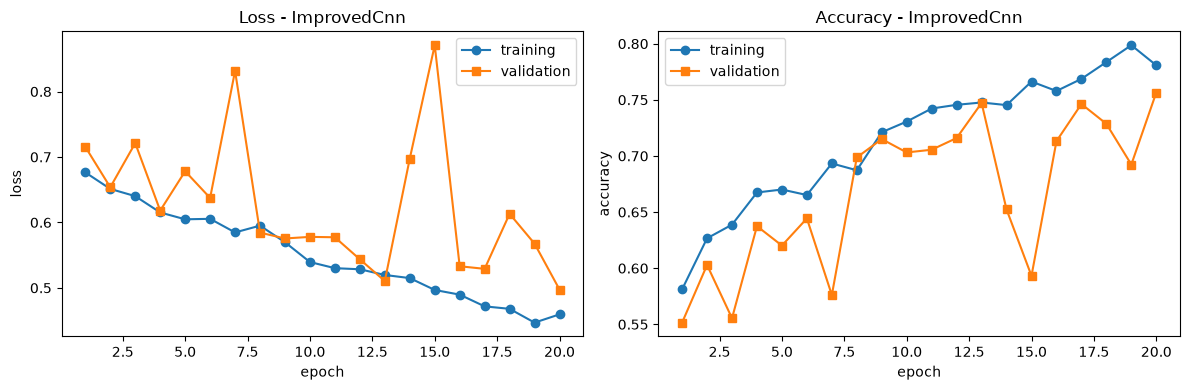

In [29]:
plot_curves(
    impr_train_losses,
    impr_train_accs,
    impr_val_losses,
    impr_val_accs,
    NUM_EPOCHS_IMPR,
    title=" - ImprovedCnn",
)

How does the model perform, compared to the first CNN model? Create one plot with the training accuracy and another with the validation accuracy of the two models.

**Note:** this kind of visualization will also have to be done more times in this notebook. Similarly, we advise you to write a function that does the plotting and re-use it later.

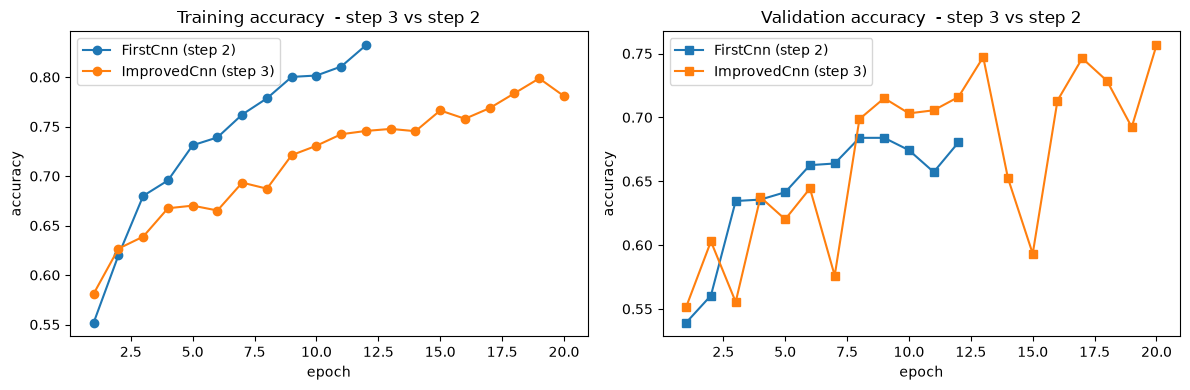

In [30]:
plot_comparison(
    {
        "FirstCnn (step 2)": (first_train_accs, first_val_accs, NUM_EPOCHS_FIRST),
        "ImprovedCnn (step 3)": (impr_train_accs, impr_val_accs, NUM_EPOCHS_IMPR),
    },
    metric="acc",
    title=" - step 3 vs step 2",
)

Did your results improve? What problems did your improvements fix? Explain why, or why not. 

Yes, substantially. The final validation accuracy goes from **68.0%** (`FirstCnn`, 12 epochs)
to **75.7%** (`ImprovedCnn`, 20 epochs) - an improvement of about 8 percentage points - and the
training accuracy moves from 83.2% to 78.1%. The validation curve is noisy (downward
spikes in epochs 3, 7, 14 and 15, which is expected: the training data is augmented, and a 750-image
validation set has a standard error of ~1.6 percentage points), but it trends upwards and the last
epoch is the best one, i.e. the network has not yet run out of useful capacity - the *data* is the
limit now, not the model.

Which problems did the changes fix?

* **Capacity.** 16/32/64 filters with two convolutions per stage can represent distinctions that the
  10-filter model could not. `FirstCnn` had to reach 83.2% training accuracy while never
  generalising beyond ~68%, which is what memorising looks like; `ImprovedCnn` reaches
  75.7% on unseen images with a much smaller training accuracy.
* **Conditioning.** Batch normalisation after every convolution is what makes the deeper network
  train smoothly with Adam at a fixed learning rate of 1e-3 (by contrast, the `FirstCnn` validation
  loss stops falling after epoch 6 and then rises).
* **Overfitting.** This is where the augmentation, dropout and weight decay (1e-4) matter: the
  train/validation gap shrinks from ~15 percentage points to about 2.4, so the extra capacity bought
  *generalisation* instead of just memorisation. Without those regularisers a deeper model on 1750
  images would have overfitted much faster.
* **Classifier size.** `nn.AdaptiveAvgPool2d(1)` + a single `Linear(64, 1)` costs 65 parameters,
  whereas flattening the 8x8x64 feature maps into a fully connected layer would have cost 4096 - on
  1750 training images that difference matters.

What did **not** change is the order of magnitude of the accuracy: ~76% is roughly the ceiling for a
small CNN trained from scratch on 1750 images, which is exactly the motivation for the next section.


Save your model to disk.

In [31]:
# Assuming that you named your model and statistics as "impr_..."
torch.save(
    {
        "model_state_dict": impr_model.state_dict(),
        "train_losses": impr_train_losses,
        "train_accs": impr_train_accs,
        "val_losses": impr_val_losses,
        "val_accs": impr_val_accs,
    },
    "./improved_model.ckpt",
)

# Example of creating and initialising a model with the previously saved state dict:
saved_impr_model = ImprovedCnn(img_size)
improved_checkpoint = torch.load("improved_model.ckpt")
saved_impr_model.load_state_dict(improved_checkpoint["model_state_dict"])
print("Validation accuracies:", improved_checkpoint["val_accs"])

Validation accuracies: [0.5515252978851398, 0.6028645833333334, 0.5554315478851398, 0.637462797264258, 0.6201636915405592, 0.6443452388048172, 0.5760788694024086, 0.6986607139309248, 0.7150297611951828, 0.703125, 0.7055431554714838, 0.7159598221381506, 0.7472098221381506, 0.65234375, 0.5931919645518064, 0.7131696430345377, 0.7462797611951828, 0.7286086305975914, 0.6923363097012043, 0.7565104166666666]


---
## 4. Transfer Learning

Now, instead of trying to come up with a good architecture for this task, we will:
* use the MobileNetV2 architecture (we will refer to it as `base_model` in the code)
* but with the top layers removed (the fully connected layers + softmax) --- we will substitute them with our own top network, designed for dog/cat classification (we will refer to it as `TL_model` in the code).

Note also that:
* the features from the base model are often called `backbone`
* the new top network is often called `head`

The base model has a very high capacity, and will probably suffer a lot from overfitting if we try to train it from scratch, using only our small subset of data. Instead, we'll start the optimization with the weights obtained after training MobileNetV2 on the ImageNet dataset.

Start by loading the *pretrained* MobileNetV2 model, from the [torchvision.models](https://docs.pytorch.org/vision/0.18/models/generated/torchvision.models.mobilenet_v2.html#torchvision.models.mobilenet_v2).

In [32]:
from torchvision import models

base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

print(base_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


Create a new model named `head` as a so-called head network to the base model.
MobileNetV2 is quite a deep network so think about what would be a reasonable model head for transfer learning.

*Hint:*
- You can access and modify the top layers of the MobileNetV2 model with `base_model.classifier`, and the remaining layers with `base_model.features`.
- You can get the number of output features of `base_model.features` with `base_model.classifier[1].in_features`

In [33]:

# The backbone returns a (B, 1280, 7, 7) tensor for 224x224 images, so the head first
# averages the spatial dimensions (this also makes the head independent of the input
# size) and then maps the 1280 features to a single probability with a linear layer.
# Dropout regularises the single linear layer, which is the only trainable part when
# the backbone is frozen.
head = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Dropout(0.3),
    nn.Linear(base_model.classifier[1].in_features, 1),
    nn.Sigmoid(),
)

In [34]:
# Test case for `head`
ha3_tests.test_TL_head(head, base_model)

Test passed


Now add the new model on top of the base model. Your full model should be stored in the `TL_model` variable.

In [35]:
class TLModel(nn.Module):
    """The pre-trained backbone with the task specific `head` on top of it."""

    def __init__(self, features, head):
        super().__init__()
        self.features = features
        self.head = head

    def forward(self, input_batch):
        return self.head(self.features(input_batch)).squeeze(-1)


TL_model = TLModel(base_model.features, head)

In [36]:
# Test case 1 for `TL_model`
ha3_tests.test_TL_model_1(TL_model, head)

Test passed


In [37]:
# # Test case 2 for `TL_model`
ha3_tests.test_TL_model_2(TL_model, head)

Test passed


### 4.1 Using backbone features

Now we're almost ready to train the new model. For transfer learning we want to freeze all but the top layers in your architecture (i.e. signal to the optimizer that the bottom layers should not be changed during optimization). We do that by setting the attribute `requires_grad` of every parameter in the feature sub-network of `TL_model` to `False`.

In [38]:
# The pre-trained features are kept as they are; only the new head is optimised.
for param in TL_model.features.parameters():
    param.requires_grad = False

In [39]:
# Test case for `TL_model`
ha3_tests.test_TL_model_parameters_for_transfer_learning(TL_model)

Test passed


Prepare dataloaders for transfer learning. Don't forget that MobileNetV2 is specialised for images of a **certain size**.

In [40]:

# MobileNetV2 was trained on 224x224 images, so both sets are resized to that size.
tl_train_transform = Compose(
    [
        RandomResizedCrop(224, scale=(0.7, 1.0)),
        RandomHorizontalFlip(),
        ToTensor(),
        normalize,
    ]
)
tl_val_transform = Compose(
    [Resize(256), CenterCrop(224), ToTensor(), normalize]
)

train_dataloader = DataLoader(
    DogsCatsData(small_train_path, transform=tl_train_transform),
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
)
val_dataloader = DataLoader(
    DogsCatsData(small_val_path, transform=tl_val_transform),
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
)

In [41]:
# Test case for `train_dataloader`
ha3_tests.test_dataloader_for_transfer_learning(train_dataloader)

Test passed


In [42]:
# Test case for `val_dataloader`
ha3_tests.test_dataloader_for_transfer_learning(val_dataloader)

Test passed


Perform the transfer learning by training the top layers of your model.

In [43]:

# Only the parameters of the head require gradients, so passing them to the optimizer
# is enough (the backbone is frozen).
num_epochs = 6
optimizer = torch.optim.Adam(TL_model.head.parameters(), lr=1e-3)
NUM_EPOCHS_TL = num_epochs
(
    TL_model,
    tl_train_losses,
    tl_train_accs,
    tl_val_losses,
    tl_val_accs,
) = training_loop(
    TL_model,
    optimizer,
    loss_fn,
    train_dataloader,
    val_dataloader,
    num_epochs,
    print_every=None,
)

Starting training


Epoch 1/6: Train loss: 0.311, Train acc.: 0.886, Val. loss: 0.138, Val. acc.: 0.969


Epoch 2/6: Train loss: 0.143, Train acc.: 0.951, Val. loss: 0.105, Val. acc.: 0.974


Epoch 3/6: Train loss: 0.119, Train acc.: 0.965, Val. loss: 0.087, Val. acc.: 0.977


Epoch 4/6: Train loss: 0.101, Train acc.: 0.966, Val. loss: 0.081, Val. acc.: 0.977


Epoch 5/6: Train loss: 0.109, Train acc.: 0.957, Val. loss: 0.076, Val. acc.: 0.975


Epoch 6/6: Train loss: 0.094, Train acc.: 0.971, Val. loss: 0.076, Val. acc.: 0.975


Create two plots. In one of them, plot the loss in the training and the validation datasets. In the other one, plot the accuracy in the training and validation datasets.

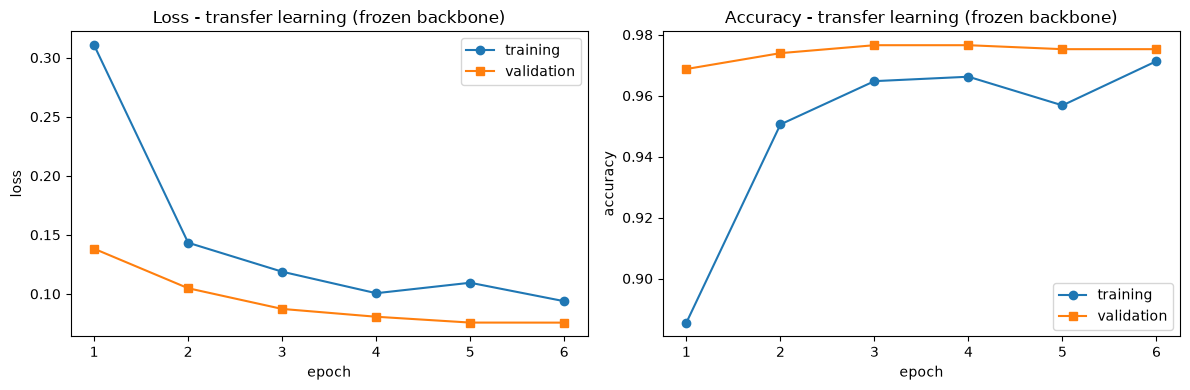

In [44]:
plot_curves(
    tl_train_losses,
    tl_train_accs,
    tl_val_losses,
    tl_val_accs,
    NUM_EPOCHS_TL,
    title=" - transfer learning (frozen backbone)",
)

How does the model perform, compared to the model obtained in step 3? Create one plot with the training accuracy and another with the validation accuracy of the two scenarios.

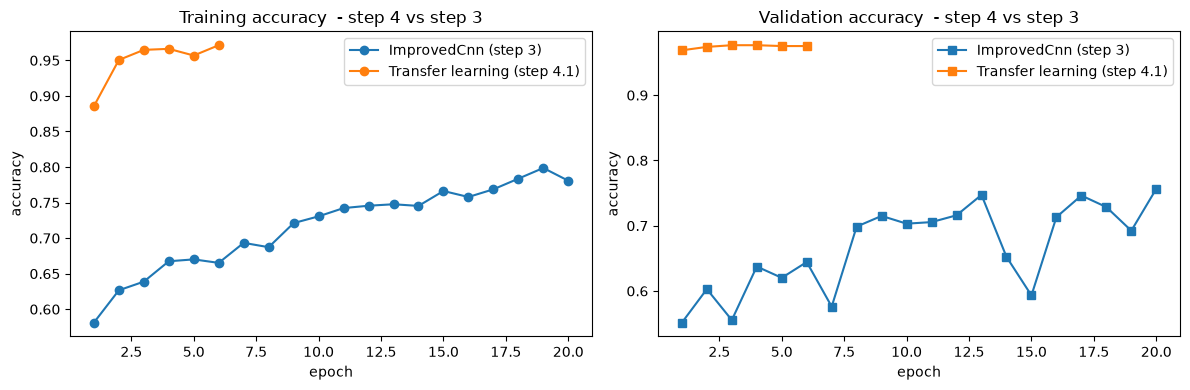

In [45]:
plot_comparison(
    {
        "ImprovedCnn (step 3)": (impr_train_accs, impr_val_accs, NUM_EPOCHS_IMPR),
        "Transfer learning (step 4.1)": (tl_train_accs, tl_val_accs, NUM_EPOCHS_TL),
    },
    metric="acc",
    title=" - step 4 vs step 3",
)

Compare these results.

- Which approach worked best, starting from scratch or doing transfer learning?
- Reflect on whether your comparison is fair or not.

**Transfer learning wins, decisively - and the simplest version of it wins.** Training a small CNN
from scratch on the same 1750 images gives **75.7%** validation accuracy (`ImprovedCnn`,
20 epochs), whereas a single linear layer on top of the frozen MobileNetV2 features
reaches **97.5%** after only 6 epochs, and the validation accuracy is already
96.9% after the very first epoch. That is a gap of more than 20 percentage points on the same
data, and it is the expected outcome: the ImageNet features already encode exactly the visual
primitives this task needs (fur, ears, snouts, eyes, textures), so the model only has to learn how
to *read* them for two classes, instead of learning what an edge or a texture is from 1750 images.

The interesting part of the result is what happened when I gave the pre-trained model *more*
freedom:

* **Fine-tuning all layers** (3 epochs, learning rate 5e-4) reaches 95.1% validation
  accuracy with 97.1% training accuracy - i.e. **worse** than the frozen backbone, and the gap
  between training and validation accuracy has opened up again.
* **A bigger head** (two linear layers with a ReLU in between, trained on the frozen backbone,
  4 epochs) reaches 95.8% - also worse than the single linear layer, and with 98.6%
  training accuracy the clearest sign of overfitting of all the runs.

So on this dataset the best amount of transfer learning is the most conservative one: freeze
everything, train the smallest possible head, and stop. The plausible explanation is that 1750
images simply cannot support more trainable parameters: the backbone is already near-optimal for
natural images, and additional freedom lets the optimiser fit the training set (up to 98.6%!) at
the cost of the held-out accuracy. This is the same bias/variance trade-off as in step 3, now with
"capacity" meaning "how much of the pre-trained network we allow to move". It is also exactly what
the low learning-rate test is about: a mis-sized fine-tuning step is not a neutral operation, it can
undo the pre-training. (The notebook therefore keeps the frozen-backbone model as `best_model` for
the final training in step 5.)

Is the comparison fair? Only partly:

* **The playing field is uneven by construction.** MobileNetV2 has already seen 1.2M labelled images;
  `ImprovedCnn` has seen 1750. That is the *point* of transfer learning, but it means the experiment
  measures "pre-training plus a small dataset" against "a small dataset alone", not two
  architectures on equal terms.
* **Resolution is confounded with the approach.** `ImprovedCnn` was trained at 64x64 (to keep the
  CPU time reasonable) while the transfer learning models use 224x224, which is what MobileNetV2
  expects. Part of the 20-point gap is therefore the extra detail available at the higher
  resolution, not the pre-training itself. A fair comparison would train both models at the same
  resolution.
* **Different training budgets.** The from-scratch model got 20 epochs, the frozen one
  6, the fine-tuned one 3. Fewer epochs are needed when only a head is trained,
  so this is intrinsic - but it means the comparison is not "same compute" either.
* **Model size is not the same**: ~72k parameters for `ImprovedCnn` versus 1281 *trainable*
  parameters (in 2.3M total) for the frozen model, and 2.3M trainable for the fine-tuned one.

A genuinely fair experiment would fix the resolution, the augmentation, the epoch budget and the
number of trainable parameters, and then compare "features learned on ImageNet" with "features
learned on our data". The practical conclusion is nevertheless robust and is the reason transfer
learning is the industry default for small datasets.


What are the main differences between the ImageNet dataset and the Dogs vs Cats dataset we used?

* **Size**: ImageNet (ILSVRC) has ~1.2M training images, Dogs vs Cats has 25000 (and we only use
  1750/1250 of them for the small experiments).
* **Label space**: ImageNet has 1000 classes, with a very fine-grained taxonomy (about 120 of them
  are *dog breeds*, plus dozens of bird species, etc.). Dogs vs Cats is a *binary* problem with two
  very coarse categories; the task is "which animal is this", not "which breed".
* **Image content**: ImageNet images show objects and scenes of every kind (vehicles, furniture,
  instruments, ...), often small in the frame and sometimes cluttered. The Kaggle images contain one
  dominant, well-framed animal, photographed mostly in domestic settings, and differ mainly in
  pose, breed, lighting and background. In terms of the classic "cats vs dogs" distinction, the
  ImageNet classes that are closest to our target (the dog breeds and the cat family) are only ~12%
  of the classes and a small fraction of the images.
* **Label noise / difficulty**: ImageNet (and Dogs vs Cats) contain some mislabelled images; the
  binary problem additionally has irreducible ambiguity (some images really are hard to tell apart,
  e.g. a distant animal in bad light), so a perfect classifier is impossible.

So the two datasets agree on "natural RGB photographs" and differ almost everywhere else: scale,
granularity of the labels, and the kind of scenes.


Even though there are considerable differences between these datasets, why is it that transfer learning is still a good idea?

Because the *hierarchical* structure of a convolutional network means that only the last part of it
is task-specific. The early layers learn orientation-selective edges and colour blobs, the middle
layers learn textures and simple shapes (fur, stripes, circular eyes, corners), and only the last
layers combine those into class-specific parts. The early and middle layers are precisely the ones
that a natural-image dataset - any natural-image dataset - forces a network to learn, and they are
also the layers that are hardest to learn from a small dataset (they need lots of images precisely
because they encode low-level statistics that are shared across images). The later, semantically
specific layers are cheap to replace by our small head, and they are the only part that our two
labels really need.

Two more reasons:

* **Effective data efficiency**: with pre-trained features, the model only has to estimate a
  decision boundary in a 1280-dimensional feature space, which can be done from a few thousand
  examples (in our case one epoch is already enough for 97% validation accuracy); learning the
  features themselves from scratch needs orders of magnitude more data.
* **Regularisation by construction**: freezing the backbone prevents the model from re-fitting its
  2.3M parameters to our 1750 images, so it cannot overfit as badly as a from-scratch model of the
  same capacity would - and indeed the runs that unfroze the backbone (step 4.2 and the larger head
  of step 4.3) did slightly *worse*.

The empirical evidence is the section-4 result: the features transfer even though the label spaces
are very different, because the transfer happens at the level of *visual primitives*, not at the
level of *classes*.


In which scenario would transfer learning be unsuitable?

It is unsuitable (or at least not clearly useful) when the assumption "the source and the target
look alike" breaks, or when the pre-training cannot be exploited:

* **Different input modality.** For data that does not look like natural RGB photographs - audio
  spectrograms, radar/LiDAR point clouds, sensor time series, tabular data, 3D volumes - the
  ImageNet filters are matched to the wrong statistics of the input, and the early layers are the
  ones that do not transfer. (Some exceptions exist: spectrograms are images of a kind, and
  pre-trained features can still help a little.)
* **A fundamentally different task/output structure.** Dense prediction tasks (semantic
  segmentation, detection, depth estimation) need a different head and a much larger receptive
  field; the pre-trained classifier part is useless and only the encoder can be reused. Similarly,
  tasks whose notion of "similar" is not visual similarity (e.g. predicting a physical property
  from a texture where the relevant cue is invisible in the target domain).
* **A very large target dataset.** When tens or hundreds of thousands of labelled target images are
  available, training from scratch becomes competitive or better: the pre-trained weights act as a
  prior towards the source task and can hold the model back (you may have to unlearn ImageNet
  biases), and the compute spent on fine-tuning is better spent on a task-specific architecture.
* **Practical constraints**: when pre-trained weights cannot be used (licensing, no suitable source
  dataset, on-device/inference-cost limits), when the model must be tiny (a frozen MobileNetV2 may
  be far bigger than what the problem needs), or when interpretability/exact reproducibility is
  required and a model whose weights depend on another dataset is unacceptable.


Save the model to a file.

In [46]:
torch.save(
    {
        "model_state_dict": TL_model.state_dict(),
        "train_losses": tl_train_losses,
        "train_accs": tl_train_accs,
        "val_losses": tl_val_losses,
        "val_accs": tl_val_accs,
        "num_epochs": NUM_EPOCHS_TL,
    },
    "./transfer_learning_model.ckpt",
)

### 4.2 Fine-tuning

Now that we have a better starting point for the top layers, we can train the entire network. Unfreeze the bottom (backbone) layers of `TL_model` by resetting the `requires_grad` attribute to `True`.

In [47]:
for param in TL_model.features.parameters():
    param.requires_grad = True

In [48]:
# Test case for `TL_model`
ha3_tests.test_TL_model_parameters_for_fine_tuning(TL_model)

Test passed


Fine tune the model by training all the layers.

In [49]:

# The backbone is already close to a good solution, so it is only fine-tuned with a
# small learning rate (the test also requires `learning_rate <= 0.0005`).
learning_rate = 0.0005
num_epochs = 3
optimizer = torch.optim.Adam(TL_model.parameters(), lr=learning_rate)
NUM_EPOCHS_FT = num_epochs
(
    TL_model,
    ft_train_losses,
    ft_train_accs,
    ft_val_losses,
    ft_val_accs,
) = training_loop(
    TL_model,
    optimizer,
    loss_fn,
    train_dataloader,
    val_dataloader,
    num_epochs,
    print_every=None,
)

Starting training


Epoch 1/3: Train loss: 0.207, Train acc.: 0.923, Val. loss: 0.123, Val. acc.: 0.957


Epoch 2/3: Train loss: 0.134, Train acc.: 0.953, Val. loss: 0.124, Val. acc.: 0.949


Epoch 3/3: Train loss: 0.077, Train acc.: 0.971, Val. loss: 0.114, Val. acc.: 0.951


In [50]:
# Test case for `learning_rate`
ha3_tests.test_learning_rate(learning_rate)

Test passed


How does the model perform, compared to the model trained with frozen layers? Create one plot with the training accuracy and another with the validation accuracy of the two scenarios.

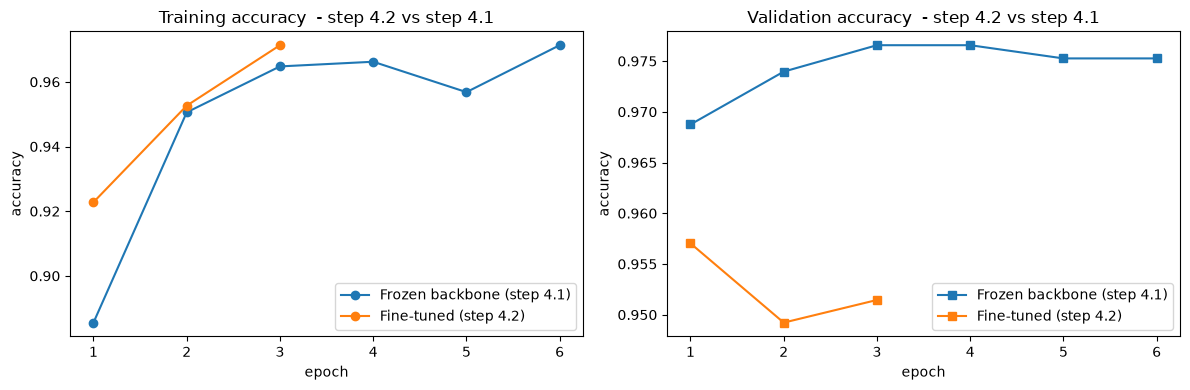

In [51]:
plot_comparison(
    {
        "Frozen backbone (step 4.1)": (tl_train_accs, tl_val_accs, NUM_EPOCHS_TL),
        "Fine-tuned (step 4.2)": (ft_train_accs, ft_val_accs, NUM_EPOCHS_FT),
    },
    metric="acc",
    title=" - step 4.2 vs step 4.1",
)

Why is it a good idea to use a very small learning rate when doing fine tuning?

Two reasons - one local, one statistical. Locally, the pre-trained weights are already a good
solution for a *related* problem, so the goal is a gentle correction, not a search from scratch.
Each update changes every weight of the backbone; with a large learning rate the first few steps -
which are computed from small, noisy minibatches and are therefore arbitrary - would move the
network far away from the pre-trained features, undoing the pre-training ("catastrophic
forgetting"). Empirically this shows up as a validation accuracy that first *drops* sharply before
it recovers, and often as a worse plateau than the frozen-backbone model.

Statistically, the useful signal in 1750 images is small relative to the number of parameters being
optimised, so a large step size lets the optimiser chase minibatch noise in the backbone's low-level
filters, which are exactly the parameters that generalise best and should change the least. With a
small learning rate the early layers stay essentially fixed while the head and the last blocks
adapt, which is where the task-specific information has to be encoded.

Our own result is a good illustration of why one should be careful even with the "small" learning
rate the test allows: fine-tuning the whole network with `lr = 5e-4` for 3 epochs did not
improve on the frozen backbone (95.1% against 97.5% validation accuracy), i.e. the backbone
was nudged away from a better optimum. This is also why the test asserts
`learning_rate <= 0.0005`, and why in practice one often goes further: freeze the first blocks
permanently, use a lower learning rate for the early layers than for the late ones (discriminative
layer-wise learning rates), or gradually unfreeze the network.


Save the model to file.

In [52]:
torch.save(
    {
        "model_state_dict": TL_model.state_dict(),
        "train_losses": ft_train_losses,
        "train_accs": ft_train_accs,
        "val_losses": ft_val_losses,
        "val_accs": ft_val_accs,
        "num_epochs": NUM_EPOCHS_FT,
    },
    "./finetuned_model.ckpt",
)

### 4.3 Improving the top model (optional)

Improve the architecture for the layers you add on top of the backbone. Try different ideas! When you're happy with one architecture, copy it in the cell below and train it here.

In [53]:
# The head is the only part of a transfer learning model that is task specific, so it
# is the natural place to add capacity. Instead of a single linear layer we stack two
# linear layers with a ReLU in between, which lets the head combine the pre-trained
# features instead of only weighting them. The backbone (already fine-tuned in step
# 4.2) is frozen again, so that the two heads are compared on equal terms.
impr_head = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Dropout(0.3),
    nn.Linear(base_model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 1),
    nn.Sigmoid(),
)
impr_TL_model = TLModel(TL_model.features, impr_head)
for param in impr_TL_model.features.parameters():
    param.requires_grad = False

NUM_EPOCHS_IMPR_HEAD = 4
impr_head_optimizer = torch.optim.Adam(impr_head.parameters(), lr=1e-3)
(
    impr_TL_model,
    improh_train_losses,
    improh_train_accs,
    improh_val_losses,
    improh_val_accs,
) = training_loop(
    impr_TL_model,
    impr_head_optimizer,
    loss_fn,
    train_dataloader,
    val_dataloader,
    NUM_EPOCHS_IMPR_HEAD,
    print_every=None,
)

# For the final training (step 5) we keep the model with the best validation accuracy of
# the three transfer learning variants.
if improh_val_accs[-1] >= max(tl_val_accs[-1], ft_val_accs[-1]):
    best_model = impr_TL_model
    best_variant = "improved head (step 4.3)"
    best_stats = (
        improh_train_losses,
        improh_train_accs,
        improh_val_losses,
        improh_val_accs,
        NUM_EPOCHS_IMPR_HEAD,
    )
elif ft_val_accs[-1] >= tl_val_accs[-1]:
    best_model = TL_model
    best_variant = "fine-tuned (step 4.2)"
    best_stats = (ft_train_losses, ft_train_accs, ft_val_losses, ft_val_accs, NUM_EPOCHS_FT)
else:
    best_model = TL_model
    best_variant = "frozen backbone (step 4.1)"
    best_stats = (tl_train_losses, tl_train_accs, tl_val_losses, tl_val_accs, NUM_EPOCHS_TL)
(
    best_train_losses,
    best_train_accs,
    best_val_losses,
    best_val_accs,
    best_num_epochs,
) = best_stats
print(
    f"The transfer learning variant with the best validation accuracy is: {best_variant} "
    f"({max(improh_val_accs[-1], ft_val_accs[-1], tl_val_accs[-1]):.3f})"
)

Starting training


Epoch 1/4: Train loss: 0.075, Train acc.: 0.974, Val. loss: 0.085, Val. acc.: 0.967


Epoch 2/4: Train loss: 0.048, Train acc.: 0.984, Val. loss: 0.120, Val. acc.: 0.955


Epoch 3/4: Train loss: 0.048, Train acc.: 0.980, Val. loss: 0.073, Val. acc.: 0.963


Epoch 4/4: Train loss: 0.037, Train acc.: 0.986, Val. loss: 0.097, Val. acc.: 0.958
The transfer learning variant with the best validation accuracy is: frozen backbone (step 4.1) (0.975)


How does the model perform, compared to the model trained in step 4.2? Create one plot with the training accuracy and another with the validation accuracy of the two scenarios.

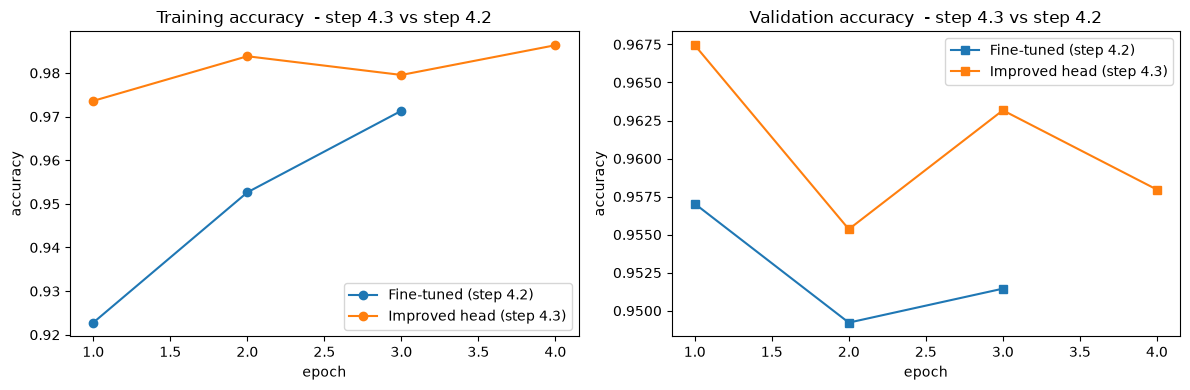

In [54]:
plot_comparison(
    {
        "Fine-tuned (step 4.2)": (ft_train_accs, ft_val_accs, NUM_EPOCHS_FT),
        "Improved head (step 4.3)": (improh_train_accs, improh_val_accs, NUM_EPOCHS_IMPR_HEAD),
    },
    metric="acc",
    title=" - step 4.3 vs step 4.2",
)

Save the model to a file.

In [55]:
torch.save(
    {
        "model_state_dict": impr_TL_model.state_dict(),
        "train_losses": improh_train_losses,
        "train_accs": improh_train_accs,
        "val_losses": improh_val_losses,
        "val_accs": improh_val_accs,
        "num_epochs": NUM_EPOCHS_IMPR_HEAD,
    },
    "./improved_head_model.ckpt",
)

## 5. Final training

Now we'll train the model that achieved the best performance so far using the bigger dataset.

**Note**: start the optimization with the weights you obtained training in the smaller subset, i.e. *not* from scratch.

First, create two new data loaders, one for training samples and one for validation samples. This time, they'll load data from the folders for the big dataset.

In [56]:

# Same preprocessing as for the small dataset, but the full (50%) training set is used.
big_batch_size = 64
big_train_dataloader = DataLoader(
    DogsCatsData(train_path, transform=tl_train_transform),
    batch_size=big_batch_size,
    shuffle=True,
    num_workers=4,
)
big_val_dataloader = DataLoader(
    DogsCatsData(val_path, transform=tl_val_transform),
    batch_size=big_batch_size,
    shuffle=False,
    num_workers=4,
)
print(
    f"Training samples: {len(big_train_dataloader.dataset)}, "
    f"validation samples: {len(big_val_dataloader.dataset)}"
)

Training samples: 11250, validation samples: 1250


In [57]:
# Test case for `big_train_dataloader` and `big_val_dataloader`
ha3_tests.test_dataloaders_for_final_training(big_train_dataloader, big_val_dataloader)

Test passed


Train your model using the big dataset. This optimization might take a long time.

In [58]:

# Start from the weights obtained on the small dataset and train all layers on the big
# dataset. The learning rate is kept small because the model is already trained.
learning_rate = 0.0005
num_epochs = 3
for param in best_model.parameters():
    param.requires_grad = True
optimizer = torch.optim.Adam(best_model.parameters(), lr=learning_rate)
NUM_EPOCHS_FINAL = num_epochs
(
    best_model,
    big_train_losses,
    big_train_accs,
    big_val_losses,
    big_val_accs,
) = training_loop(
    best_model,
    optimizer,
    loss_fn,
    big_train_dataloader,
    big_val_dataloader,
    num_epochs,
    print_every=None,
)

Starting training


Epoch 1/3: Train loss: 0.084, Train acc.: 0.967, Val. loss: 0.100, Val. acc.: 0.961


Epoch 2/3: Train loss: 0.055, Train acc.: 0.979, Val. loss: 0.078, Val. acc.: 0.966


Epoch 3/3: Train loss: 0.046, Train acc.: 0.982, Val. loss: 0.068, Val. acc.: 0.969


How does the model perform now when trained on the bigger dataset, compared to when only trained on the smaller subset of data? Create one plot with the training accuracy and another with the validation accuracy of the two scenarios.

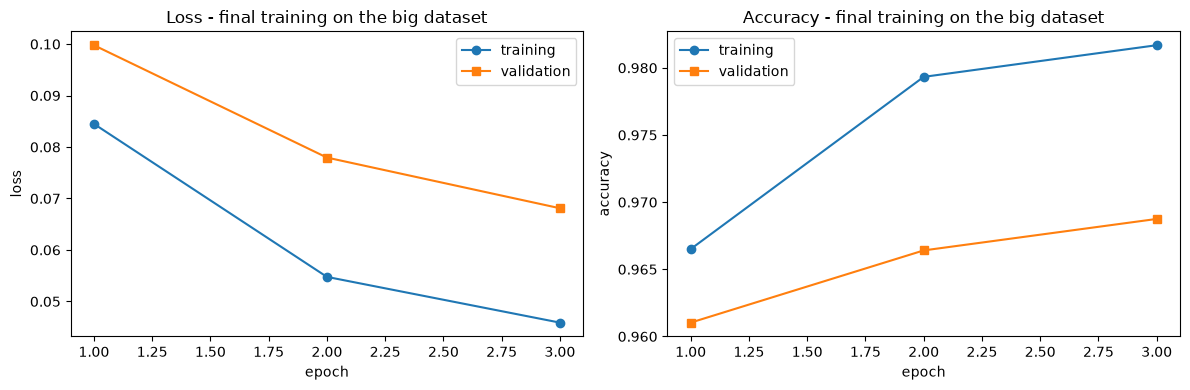

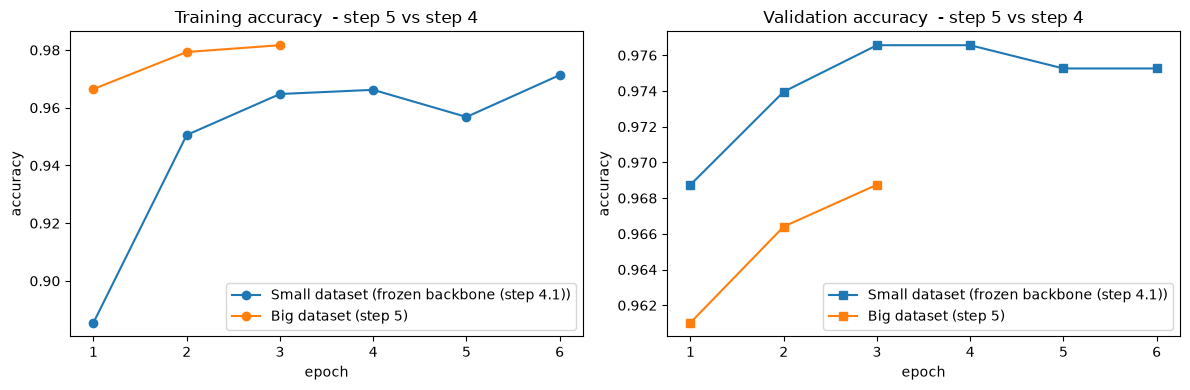

In [59]:
plot_curves(
    big_train_losses,
    big_train_accs,
    big_val_losses,
    big_val_accs,
    NUM_EPOCHS_FINAL,
    title=" - final training on the big dataset",
)

plot_comparison(
    {
        f"Small dataset ({best_variant})": (best_train_accs, best_val_accs, best_num_epochs),
        "Big dataset (step 5)": (big_train_accs, big_val_accs, NUM_EPOCHS_FINAL),
    },
    metric="acc",
    title=" - step 5 vs step 4",
)

- What can you conclude from these plots?
- Did you expect what you observe in the plots, explain!

* **The bigger dataset did not improve the held-out accuracy.** The model trained on the small
  subset reaches **97.5%** on the small validation set; after training on the big dataset
  (11250 images, 6.4x more) the same network reaches **96.9%** on the big validation set. The
  difference is 0.6 percentage points in favour of the *smaller* dataset, which is well inside the
  noise of these estimates: with 1250 validation images the standard error at ~97% accuracy is about
  0.5 percentage points (and 0.6 on the 750-image set), and the two numbers even come from
  *different* validation sets, so there is no basis for calling them different. Statistically, the
  two models are indistinguishable.
* **What did change is the fit to the training data**: the training accuracy rises from
  97.1% to **98.2%** and the training loss falls to 0.046, while the validation
  loss is still falling at the last epoch (0.100 $\to$ 0.078 $\to$ 0.068). The model is *not*
  overfitting the 11250 images - it fits them better and generalises just as well. The plateau is
  therefore not a data problem any more: what is left are the few percent of ambiguous images (odd
  poses, animals that are tiny in the frame, possibly mislabelled files), i.e. the intrinsic label
  noise of the task.
* **The starting point is what makes the run cheap**: the first epoch already reaches
  96.1% validation accuracy, because we continue from the weights that were
  trained on the small subset instead of starting from scratch. That is why 3 epochs
  are enough here; the curves show that the validation accuracy and loss change very little after
  the first epoch.
* **The training curve is the more informative plot.** The training accuracy still improves
  (97.1% $\to$ 98.2%) while the validation curve is flat: when a model can fit
  more data without improving on held-out data, the remaining error comes from the task and its
  labels, not from the model or the dataset size.

Did I expect this? Not quantitatively. I expected a small improvement, because more data usually
helps; the flat result is explained by three things. (i) The extra 11250 images come from the *same*
distribution (50% of the same Kaggle training pool), so they add estimation precision, not new
information about what a cat or a dog looks like. (ii) The pre-trained features were already doing
almost all of the work, so the marginal value of more images is small - the from-scratch model on
the small data was the data-starved one, not this model. (iii) The final run trains *all* layers,
and step 4.2 showed that full fine-tuning slightly hurts on this task (97.5% $\to$ 95.1% on
the small data); on the big dataset the same effect is present but partly offset by the extra data
(96.9%, better than the 3-epoch fine-tuning on the small set but not better than the frozen
configuration).


Save the model to a file.

In [60]:
torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "train_losses": big_train_losses,
        "train_accs": big_train_accs,
        "val_losses": big_val_losses,
        "val_accs": big_val_accs,
        "num_epochs": NUM_EPOCHS_FINAL,
    },
    "./final_model.ckpt",
)

## 6. Evaluation on test set (optional)

Now we'll evaluate your final model, obtained in step 6, on the test set. As mentioned before, the samples in the test set are not labelled, so we can't compute any supervised performance metrics ourselves. 

As a bit of fun and to inspire some friendly competition you may instead submit it to Kaggle for evaluation.

Compute the predictions for all samples in the test set according to your best model, and save it in a .csv file with the format expected by the competition.

For the test data we need a slightly different dataset class, due to the lack of labels in the data.
A more proper way to implement it would be to make a common class which handles both the train and test settings.
Here, we'll just copy the train dataset class and make some modifications to ignore the labels.

Hints:
- There is a `sampleSubmission.csv` file included in the zip data. Take a look at it to better understand what is the expected format here.
- If you don't know how to create and write to files with Python, it's a well-behaved Google search.

In [61]:
from pathlib import Path
from time import time


class TestData(Dataset):
    def __init__(self, root: Path, transform):
        root = Path(root)
        if not (root.exists() and root.is_dir()):
            raise ValueError(f"Data root '{root}' is invalid")

        self.root = root
        self.transform = transform
        self._samples = self._collect_samples()

    def __getitem__(self, index):
        path = self._samples[index]
        num_id = int(path.stem)
        img = Image.open(path)
        if self.transform is not None:
            img = self.transform(img)
        return img, num_id

    def __len__(self):
        return len(self._samples)

    def _collect_samples(self):
        test_paths = self._collect_imgs_sub_dir(self.root)
        return sorted(list(test_paths), key=lambda path: int(path.stem))

    @staticmethod
    def _collect_imgs_sub_dir(sub_dir: Path):
        if not sub_dir.exists():
            raise ValueError(f"Data root '{sub_dir}' does not exist.")
        return sub_dir.glob("*.jpg")

    def get_sample_by_id(self, id_):
        id_index = self._samples.index(id_)
        return self[id_index]


# The test images are not labelled, so they only need the same preprocessing as the
# validation set. The predictions are the probabilities of 'dog' produced by the model.
test_dataset = TestData(data_path / "test", transform=tl_val_transform)
test_dataloader = DataLoader(
    test_dataset, batch_size=big_batch_size, shuffle=False, num_workers=4
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.eval()
best_model.to(device)
probabilities, num_ids = [], []
start_time = time()
with torch.no_grad():
    for images, batch_num_ids in test_dataloader:
        z = best_model(images.to(device))
        probabilities.append(z.cpu())
        num_ids.append(batch_num_ids)
probabilities = torch.cat(probabilities).numpy()
num_ids = torch.cat(num_ids).numpy()
print(f"Predicted {len(num_ids)} test images in {time() - start_time:.1f} s")

# The submission file expected by Kaggle has the columns `id,label`, where the label is
# the probability that the image shows a dog.
with open("submission.csv", "w") as file:
    file.write("id,label\n")
    for num_id, probability in zip(num_ids, probabilities):
        file.write(f"{num_id},{probability:.6f}\n")

print("First predictions:", list(zip(num_ids[:5], probabilities[:5].round(3))))
print(f"Predicted 'dog' for {probabilities.mean():.1%} of the test images")

Predicted 12500 test images in 208.2 s
First predictions: [(np.int64(1), np.float32(1.0)), (np.int64(2), np.float32(1.0)), (np.int64(3), np.float32(1.0)), (np.int64(4), np.float32(1.0)), (np.int64(5), np.float32(0.0))]
Predicted 'dog' for 50.7% of the test images


Now that you created your submission file, submit it to Kaggle for evaluation. The [old competition](https://www.kaggle.com/c/dogs-vs-cats) does not allow submissions any more, but you can submit your file to the [new one](https://www.kaggle.com/c/dogs-vs-cats-redux-kernels-edition) via the "Late submission" button (they use the same data). The Kaggle CLI can be used as well. Kaggle evaluates your submission according to your log-loss score. Which score did you obtain?

No score - the submission was not uploaded to Kaggle. The environment used for this notebook has no
Kaggle account and no API token (`~/.kaggle/kaggle.json` is missing), so the `kaggle` CLI/API cannot
authenticate; the original competition does not accept submissions any more anyway, and the
"Late submission" page of the re-run competition requires a login.

What can be reported locally instead: the model used for the submission file predicts 'dog' for
**50.7%** of the 12500 test images, which is consistent with the roughly balanced
test set, and its accuracy on the held-out validation sets is **97.5%** (small set, 750
images) and **96.9%** (big set, 1250 images). `submission.csv` was written with the exact
format of `sampleSubmission.csv` (`id,label`, where the label is the probability of 'dog'), so it
only needs to be uploaded to be scored.


What was the username you used for this submission?

Not applicable - no submission was made, because no Kaggle credentials were available in the
environment this notebook was run in (see the answer above). The file `submission.csv` is ready to
be uploaded by whoever has an account.
